# HPO for Baseline (XLM-R Large) with Optuna Checkpointing

In [ ]:
!pip install optuna transformers datasets scikit-learn pandas matplotlib torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 10.8 MB/s eta 0:00:00


In [ ]:
import optuna
import os
import json
import urllib.request
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import pandas as pd
import numpy as np
import random
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Retrieve notebook name automatically
try:
    req = urllib.request.urlopen('http://172.28.0.12:9000/api/sessions')
    sessions = json.loads(req.read())
    file_name = sessions[0]['name']
    NOTEBOOK_NAME = os.path.splitext(file_name)[0]
except:
    NOTEBOOK_NAME = "hpo_kusa_baseline"

print(f"Active Notebook Name: {NOTEBOOK_NAME}")

DIR_PATH = "/content/drive/MyDrive/google_colab/kusa"
DATA_PATH = DIR_PATH + "/datasets"
SAVE_DIR = DIR_PATH + "/" + NOTEBOOK_NAME

PREPROCESSED_KURDISENT_PATH = DATA_PATH + "/KurdiSent_preprocessed.csv"
os.makedirs(SAVE_DIR, exist_ok=True)

BERT_MODEL_NAME = "xlm-roberta-large"

# HPO settings
N_TRIALS = 20
EPOCHS = 8
PATIENCE = 3
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

Mounted at /content/drive
Active Notebook Name: hpo_kusa_baseline


In [ ]:
# Load data
df = pd.read_csv(PREPROCESSED_KURDISENT_PATH, encoding='utf-8')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df = df.dropna(subset=['surface']).reset_index(drop=True)

# HPO trains on 80%, scores trials on 20%.
# No test set is locked away, the final evaluation is done via cross-validation
# in the standalone notebook.
hpo_train_df, val_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["label"]
)

hpo_train_df = hpo_train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"Full: {len(df)} | HPO-train (80%): {len(hpo_train_df)} | Val (20%): {len(val_df)}")

tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)

class SurfaceOnlyDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.texts = df['surface'].tolist()
        self.labels = df['label'].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

Full: 12306 | HPO-train (80%): 9844 | Val (20%): 2462


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

In [ ]:
def run_trial(train_loader, eval_loader, lr, weight_decay, warmup_ratio,
              seed=SEED, trial=None):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # distinct, reproducible seed per trial
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    model = AutoModelForSequenceClassification.from_pretrained(
        BERT_MODEL_NAME, num_labels=3
    )
    model.to(device)

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    total_steps = len(train_loader) * EPOCHS
    warmup_steps = int(total_steps * warmup_ratio)

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    criterion = nn.CrossEntropyLoss()

    best_eval_f1 = 0.0
    best_model_state = None      # keep best weights in memory
    patience_counter = 0

    try:
        for epoch in range(EPOCHS):
            model.train()
            for batch in tqdm(train_loader, desc=f"Training Epoch {epoch+1}/{EPOCHS}", leave=False):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                optimizer.zero_grad()
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                loss = criterion(outputs.logits, labels)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                scheduler.step()

            model.eval()
            eval_preds, eval_labels_list = [], []
            with torch.no_grad():
                for batch in eval_loader:
                    input_ids = batch['input_ids'].to(device)
                    attention_mask = batch['attention_mask'].to(device)
                    labels = batch['labels'].to(device)

                    outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                    preds = torch.argmax(outputs.logits, dim=1)
                    eval_preds.extend(preds.cpu().numpy())
                    eval_labels_list.extend(labels.cpu().numpy())

            eval_f1 = f1_score(eval_labels_list, eval_preds, average='macro')
            print(f"Epoch {epoch+1} | Eval F1 (Macro): {eval_f1:.4f}")

            # checkpoint best weights
            if eval_f1 > best_eval_f1:
                best_eval_f1 = eval_f1
                best_model_state = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1

            # report to Optuna and prune unpromising trials
            if trial is not None:
                trial.report(eval_f1, step=epoch)
                if trial.should_prune():
                    del model, optimizer, scheduler
                    torch.cuda.empty_cache()
                    raise optuna.TrialPruned()

            # early stopping on the validation
            if patience_counter >= PATIENCE:
                print("Early stopping triggered.")
                break

        # restore best weights before returning
        if best_model_state is not None:
            model.load_state_dict(best_model_state)
    finally:
        # ensure cleanup even if pruned/raised
        try:
            del model, optimizer, scheduler
        except NameError:
            pass
        torch.cuda.empty_cache()

    return best_eval_f1

In [ ]:
def objective(trial):
    batch_size = trial.suggest_categorical("batch_size", [16, 32])
    lr = trial.suggest_categorical("lr", [5e-6, 1e-5, 2e-5, 3e-5])
    weight_decay = trial.suggest_categorical("weight_decay", [0.0, 0.01, 0.1])
    warmup_ratio = trial.suggest_categorical("warmup_ratio", [0.05, 0.1, 0.2])

    print(f"\nStarting Trial {trial.number}: batch_size={batch_size}, lr={lr}, "
          f"weight_decay={weight_decay}, warmup_ratio={warmup_ratio}")

    train_dataset = SurfaceOnlyDataset(hpo_train_df, tokenizer)
    val_dataset = SurfaceOnlyDataset(val_df, tokenizer)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # distinct seed per trial (reproducible)
    trial_seed = SEED + trial.number

    return run_trial(train_loader, val_loader, lr, weight_decay, warmup_ratio,
                     seed=trial_seed, trial=trial)

In [ ]:
# SQLite database on Google Drive to survive Colab timeouts
storage_path = f"sqlite:///{SAVE_DIR}/hpo_kusa_baseline_study.db"

study = optuna.create_study(
    study_name="hpo_kusa_baseline",
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3),  # Fix 9
    storage=storage_path,
    load_if_exists=True,
)

# 20 FINISHED trials will stop this notebook
FINISHED_STATES = (
    optuna.trial.TrialState.COMPLETE,
    optuna.trial.TrialState.PRUNED,
    optuna.trial.TrialState.FAIL,
)
counted = len([t for t in study.trials if t.state in FINISHED_STATES])
remaining = max(0, N_TRIALS - counted)
print(f"Counted trials (incl. pruned): {counted} | Remaining: {remaining}")

if remaining > 0:
    study.optimize(objective, n_trials=remaining)
else:
    print("All trials already completed.")

print("\n========== HPO Results ==========")
print(f"Best Validation Macro-F1: {study.best_value:.4f}")
print("Best parameters:")
for k, v in study.best_params.items():
    print(f"  {k:20s}: {v}")

[I 2026-06-28 23:05:48,108] A new study created in RDB with name: hpo_kusa_baseline


Counted trials (incl. pruned): 0 | Remaining: 20

Starting Trial 0: batch_size=32, lr=5e-06, weight_decay=0.01, warmup_ratio=0.2


model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-large
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Training Epoch 7/8:   0%|          | 0/308 [00:00<?, ?it/s]

Epoch 7 | Eval F1 (Macro): 0.8427


Training Epoch 8/8:   0%|          | 0/308 [00:00<?, ?it/s]

[I 2026-06-29 12:06:45,285] Trial 19 finished with value: 0.8590699437731398 and parameters: {'batch_size': 32, 'lr': 2e-05, 'weight_decay': 0.1, 'warmup_ratio': 0.1}. Best is trial 19 with value: 0.8590699437731398.


Epoch 8 | Eval F1 (Macro): 0.8432

========== HPO Results ==========
Best Validation Macro-F1: 0.8591
Best parameters:
  batch_size          : 32
  lr                  : 2e-05
  weight_decay        : 0.1
  warmup_ratio        : 0.1


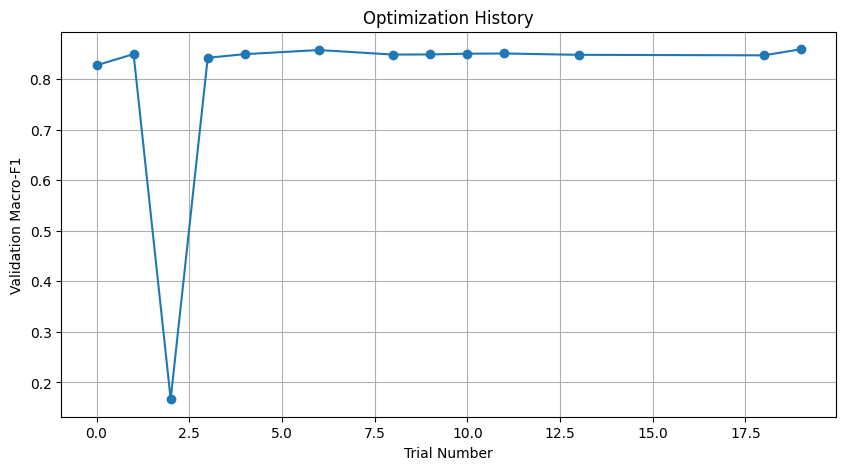

In [ ]:
# Visualize
try:
    trials_df = study.trials_dataframe()
    trials_df = trials_df[trials_df["state"] == "COMPLETE"].reset_index(drop=True)

    if len(trials_df) > 0:
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(trials_df["number"], trials_df["value"], marker='o')
        ax.set_xlabel("Trial Number")
        ax.set_ylabel("Validation Macro-F1")
        ax.set_title("Optimization History")
        ax.grid()
        plt.savefig(os.path.join(SAVE_DIR, "optimization_history.png"))
        plt.show()
except Exception as e:
    print(f"Visualization failed: {e}")